In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, train_test_split

from sklearn.svm import SVR
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, AutoLocator)
from matplotlib import ticker
from matplotlib import cm

# Load data

In [4]:
dataCondMem = pd.read_excel('data/Conductivity.xlsx').dropna()

y = np.asarray(pd.DataFrame(dataCondMem, columns=['k']))
y = np.reshape(y, (len(y), ))
X = pd.DataFrame(dataCondMem, columns=['T', 'IEC'])

# Data processing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=0)

trainset = np.column_stack((X_train, y_train))
testset = np.column_stack((X_test, y_test))

scaler = MinMaxScaler(feature_range=(-1, 1))

scaler.fit(X_train)

X_train = scaler.transform(X_train)


# Train the model

In [6]:
kernel = 'rbf'
C = 100
gamma = 5
epsilon = 0.1

model = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon)

sigma_model =model.fit(X_train, y_train)

# Evaluate model performance

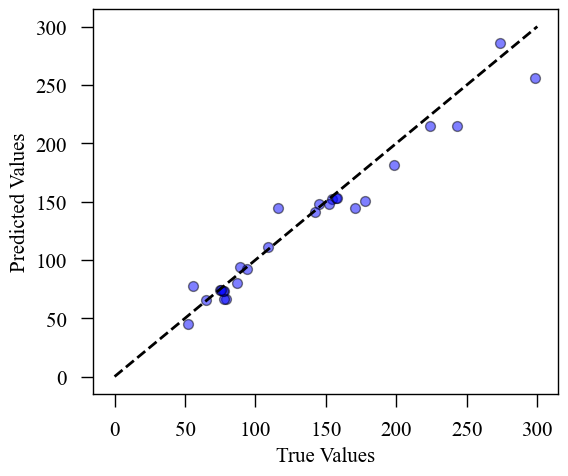

In [9]:
X_test_scaled = scaler.transform(X_test)

y_predicted = model.predict(X_test_scaled)


def plot_parity(y_test, y_predicted):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_test, y_predicted, s=50, c='blue', alpha=0.5, edgecolors='k')
    ax.plot([0, 300], [0, 300], 'k--', lw=2)

    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')

    ax.xaxis.label.set_size('medium')
    ax.yaxis.label.set_size('medium')

    ax.tick_params(direction='out',
                            pad=10,
                            length=9,
                            width=1,
                            labelsize='medium')

    ax.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='medium')

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 

    plt.savefig(f'figures/example-7-1-svr.png', dpi = 300)
    plt.show()

    return None

plot_parity(y_test, y_predicted)

# Create a function to use the model to obtain predictions

In [10]:
def conductivityMem(T, IEC): 
    X = np.array([T, IEC])
    X = scaler.transform(X.reshape(1, -1))
    sigma_mem = model.predict(X)
    return sigma_mem[0]  # Extract scalar from array

In [11]:
import warnings
warnings.filterwarnings("ignore")

T = np.linspace(0, 300, 100)
IEC = np.linspace(0, 1, 100)
T, IEC = np.meshgrid(T, IEC)
Z = np.zeros((len(T), len(IEC)))
for i in range(len(T)):
    for j in range(len(IEC)):
        Z[i, j] = conductivityMem(T[i, j], IEC[i, j])

In [12]:
def plot_surface(T, IEC, Z):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(T, IEC, Z, cmap='viridis', edgecolor='none')
    
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Ionic Conductivity (S/m)')
    ax.set_zlabel('Conductivity (S/m)')
    
    ax.set_title('Conductivity of Membrane')
    # ax.view_init(30, 210)
    
    ax.xaxis.label.set_size('medium')
    ax.yaxis.label.set_size('medium')
    ax.zaxis.label.set_size('medium')
    
    ax.tick_params(direction='out',
                                pad=5,
                                length=9,
                                width=1,
                                labelsize='medium')
    ax.tick_params(which='minor',
                            direction='out',
                            pad=5,
                            length=5,
                            width=1,
                            labelsize='medium')
    
    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                        ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1
    plt.savefig(f'figures/example-7-1-surface.png', dpi = 300)
    plt.tight_layout()
    plt.show()
    return None

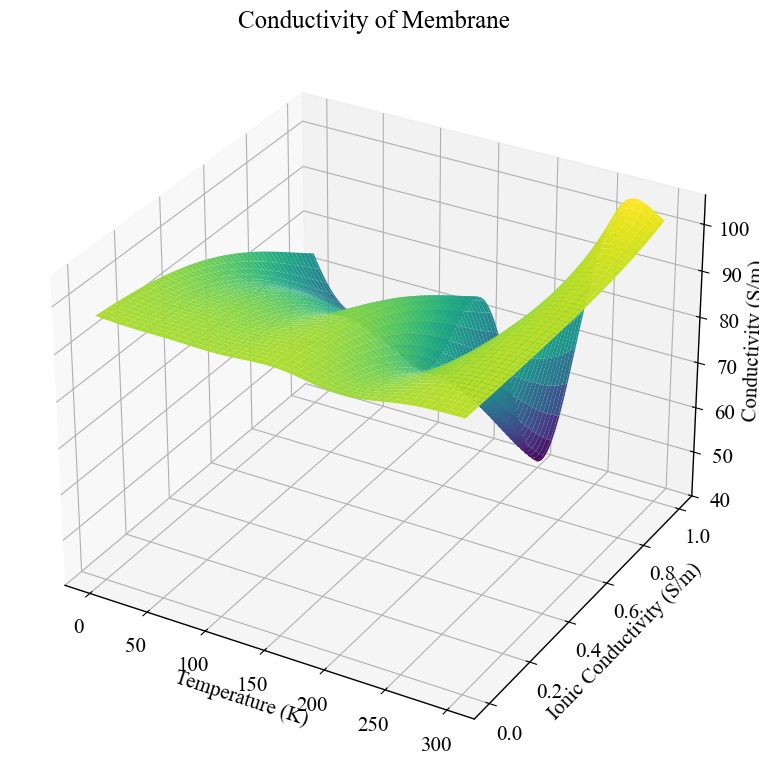

In [13]:
plot_surface(T, IEC, Z)